# Time Series - More Applications

## Anomaly Detection
- Process that enable us to identify outliers.
- Anomaly data points can cause technical issues.
- Security alerts: for example, a spike in request volume may indicate DDoS attack; multiple failing attempts for login may indicate potential cyber securities threats.
- Fraud detection: banks use anomaly detection to highlight suspicious account activities

### Data

https://www.kaggle.com/datasets/vivovinco/beehives/data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.ensemble import IsolationForest


In [1]:
df = pd.read_csv('data/Hive17.csv', sep=";")


In [2]:
df.isna().sum()

Hour          0
DateTime      0
T17           0
RH17          0
AT17          0
Tamb          0
RHamb         0
ATamb         0
T17-Tamb      0
AT17-ATamb    0
dtype: int64

In [3]:
df.head()

,Hour,DateTime,T17,RH17,AT17,Tamb,RHamb,ATamb,T17-Tamb,AT17-ATamb
0,1,21.08.2021 14:00,32.8,47,36.6,28.8,33,29.1,4.0,7.5
1,2,21.08.2021 15:00,33.3,46,37.1,28.8,36,29.5,4.5,7.6
2,3,21.08.2021 16:00,33.5,46,37.4,28.9,35,29.5,4.6,7.9
3,4,21.08.2021 17:00,33.8,49,38.5,28.5,36,29.1,5.3,9.3
4,5,21.08.2021 18:00,33.8,51,38.8,27.5,40,28.4,6.3,10.4


According to the data’s description, we know that column T17 represents the temperature of the hive, and RH17 represents the relative humidity of the hive. We’ll extract the value of these two columns as our input:

In [4]:
X = df[["T17", "RH17"]].values

#### OneClassSVM

- Support Vector Machines (SVM) can be used to classify data points in high dimensions, by choosing a kernel and a scalar parameter to define a frontier
- OneClassSVM is used to create a decision boundary that includes most of the data points (normal data), while retaining a small number of anomalies outside of the boundaries

In [7]:
estimator = OneClassSVM().fit(X)

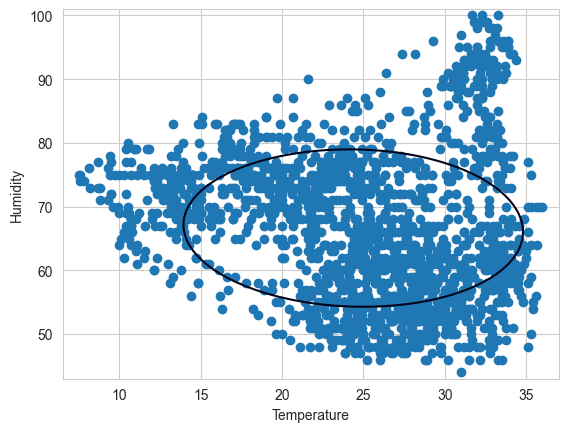

In [8]:
disp = DecisionBoundaryDisplay.from_estimator(
    estimator,
    X,
    response_method="decision_function",
    plot_method="contour",
    xlabel="Temperature", ylabel="Humidity",
    levels=[0],
)
disp.ax_.scatter(X[:, 0], X[:, 1])
plt.show()

##### Fine-tune hyperparameters

- We have two parameters: nu and gamma

1. `nu` (ν) – Anomaly Proportion Control
- Represents an **upper bound on the fraction of training errors** (i.e., outliers).
- Also represents a **lower bound on the fraction of support vectors**.
- Must be in the range **(0, 1]**.
- **Smaller `nu`** = more strict (fewer points considered anomalies).
- **Larger `nu`** = more permissive (more points can be considered anomalies).

2. `gamma` – Kernel Coefficient (for RBF, poly, sigmoid)
- Controls how far the influence of a single training example reaches.
- **High `gamma`** → short-range influence (can lead to overfitting).
- **Low `gamma`** → long-range influence (can underfit).
- For the **RBF kernel** (default), it defines the “smoothness” of the decision boundary.


In [9]:
estimator = OneClassSVM(nu=0.1, gamma=0.05).fit(X)

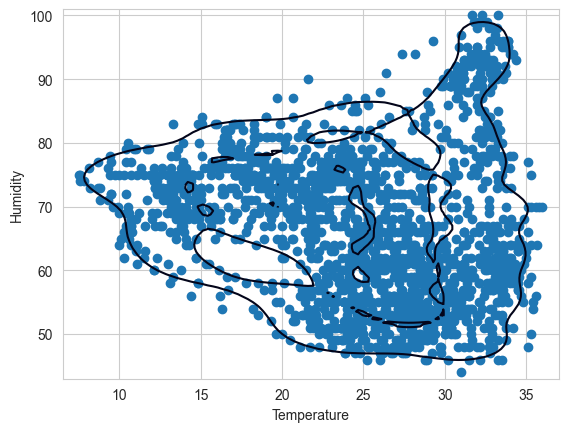

In [10]:
disp = DecisionBoundaryDisplay.from_estimator(
    estimator,
    X,
    response_method="decision_function",
    plot_method="contour",
    xlabel="Temperature", ylabel="Humidity",
    levels=[0],
)
disp.ax_.scatter(X[:, 0], X[:, 1])
plt.show()

#### Isolation Forest

- Enxembled-based method, similar to Random Forest


In [13]:
estimators = [
    OneClassSVM(nu=0.1, gamma=0.05).fit(X),
    IsolationForest(n_estimators=100).fit(X)
]

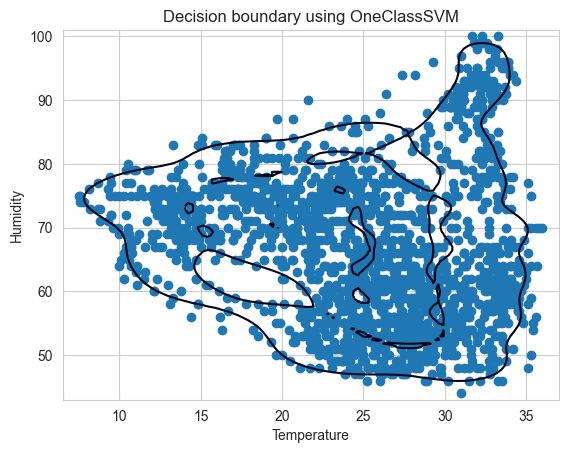

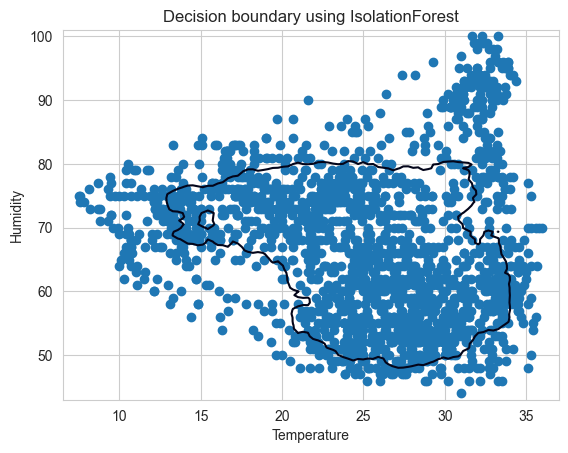

In [16]:
for estimator in estimators:
    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="decision_function",
        plot_method="contour",
        xlabel="Temperature", ylabel="Humidity",
        levels=[0],
    )
    disp.ax_.scatter(X[:, 0], X[:, 1])
    disp.ax_.set_title(
        f"Decision boundary using {estimator.__class__.__name__}"
    )
    plt.show()


## Anomaly Detection in Time Series


In [23]:
df.dtypes

Hour            int64
DateTime       object
T17           float64
RH17            int64
AT17          float64
Tamb          float64
RHamb           int64
ATamb         float64
T17-Tamb      float64
AT17-ATamb    float64
dtype: object

In [25]:
df['DateTime'] = pd.to_datetime(df['DateTime'], dayfirst=True)

In [26]:
df[['DateTime', 'T17']].head()

,DateTime,T17
0,2021-08-21 14:00:00,32.8
1,2021-08-21 15:00:00,33.3
2,2021-08-21 16:00:00,33.5
3,2021-08-21 17:00:00,33.8
4,2021-08-21 18:00:00,33.8


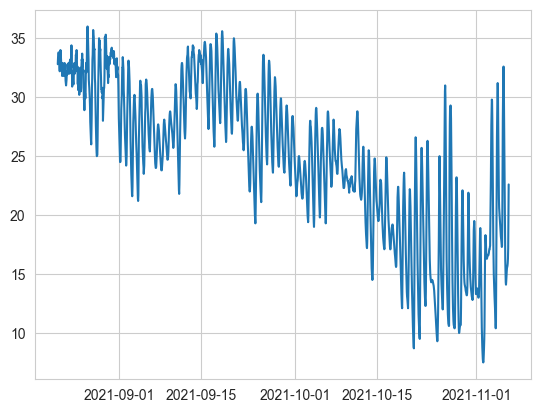

In [27]:
plt.plot(df['DateTime'], df['T17'])

When expressed as a time series, the temperature has a lot of ups and downs. This indicates periodic behavior, likely due to the day-night cycle, so it is safe to assume there is a 24-hour period for the temperature.

Next, there is a trend of temperature dropping over time. If you inspect the DateTime column, you can see that the dates range from August to November. Since the Kaggle page of the dataset indicates that the data was collected in Turkey, the transition from summer to fall explains our observation that the temperature is dropping over time.

In [28]:
from statsmodels.tsa.seasonal import STL
stl = STL(df["T17"], period=24, robust=True)
result = stl.fit()

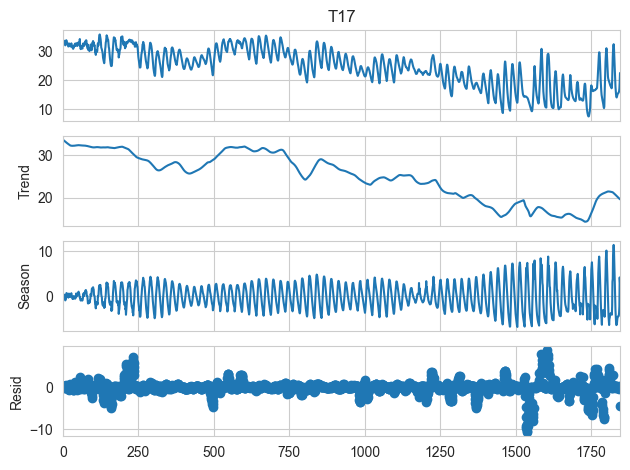

In [29]:
result.plot();

You can see the Trend and Season plots seem to align with our assumptions above. However, we are interested in the residual plot at the bottom, which is the original series without the trend and seasonal changes. Any extremely high or low value in the residual indicates an anomaly.

##### Anomaly treshold

Next, we would like to determine what values of the residual we’ll consider abnormal. To do that, we can look at the residual’s histogram.

<Axes: ylabel='Frequency'>

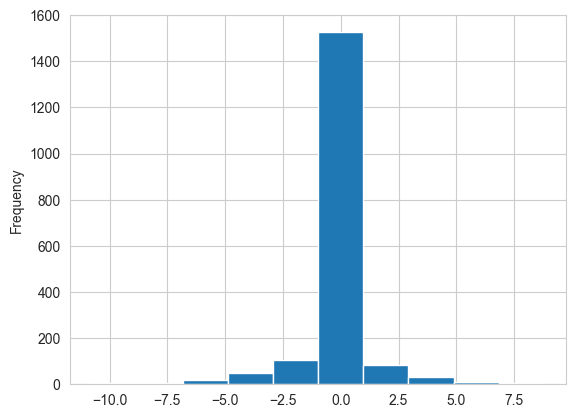

In [30]:
result.resid.plot.hist()

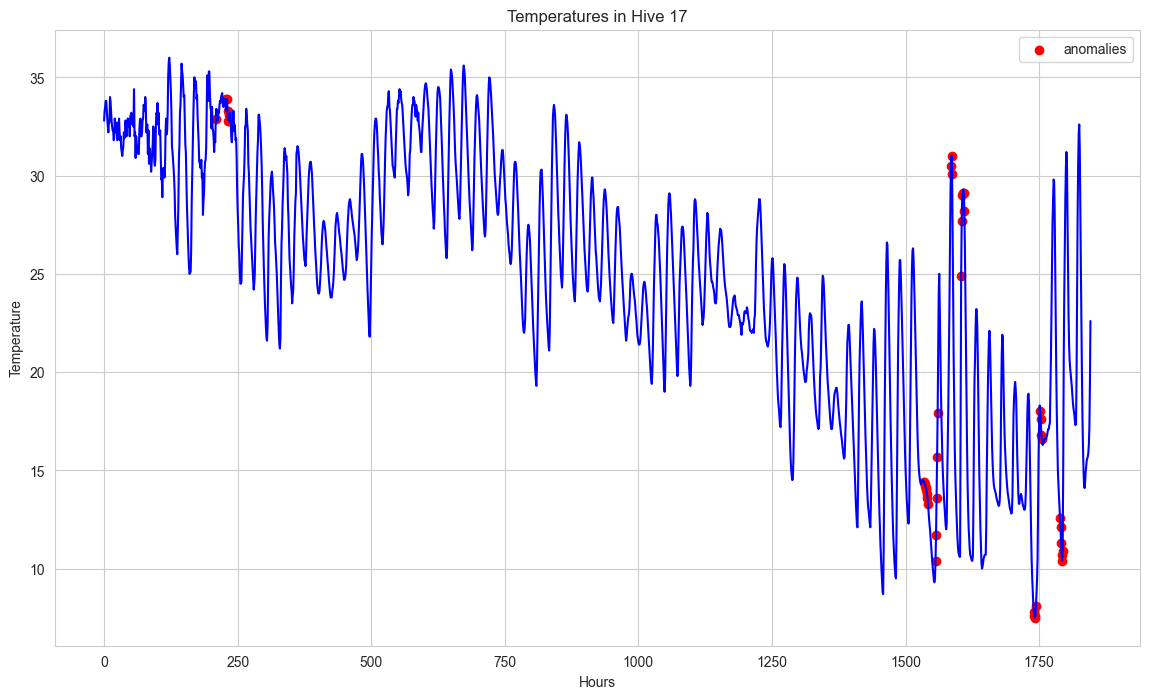

In [31]:
import matplotlib.pyplot as plt

threshold = 5
anomalies_filter = result.resid.apply(lambda x: True if abs(x) > threshold else False)
anomalies = df["T17"][anomalies_filter]

plt.figure(figsize=(14, 8))
plt.scatter(x=anomalies.index, y=anomalies, color="red", label="anomalies")
plt.plot(df.index, df['T17'], color='blue')
plt.title('Temperatures in Hive 17')
plt.xlabel('Hours')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [35]:
oneclass_model = OneClassSVM(nu=0.1, gamma=0.05).fit(X)
iforest_model = IsolationForest(n_estimators=100, random_state=42).fit(X)

df['anomaly_oneclass'] = oneclass_model.predict(X) == -1
df['anomaly_iforest'] = iforest_model.predict(X) == -1

In [36]:
stl = STL(df["T17"], period=24, robust=True)
result = stl.fit()
threshold = 5
df['anomaly_stl'] = result.resid.abs() > threshold

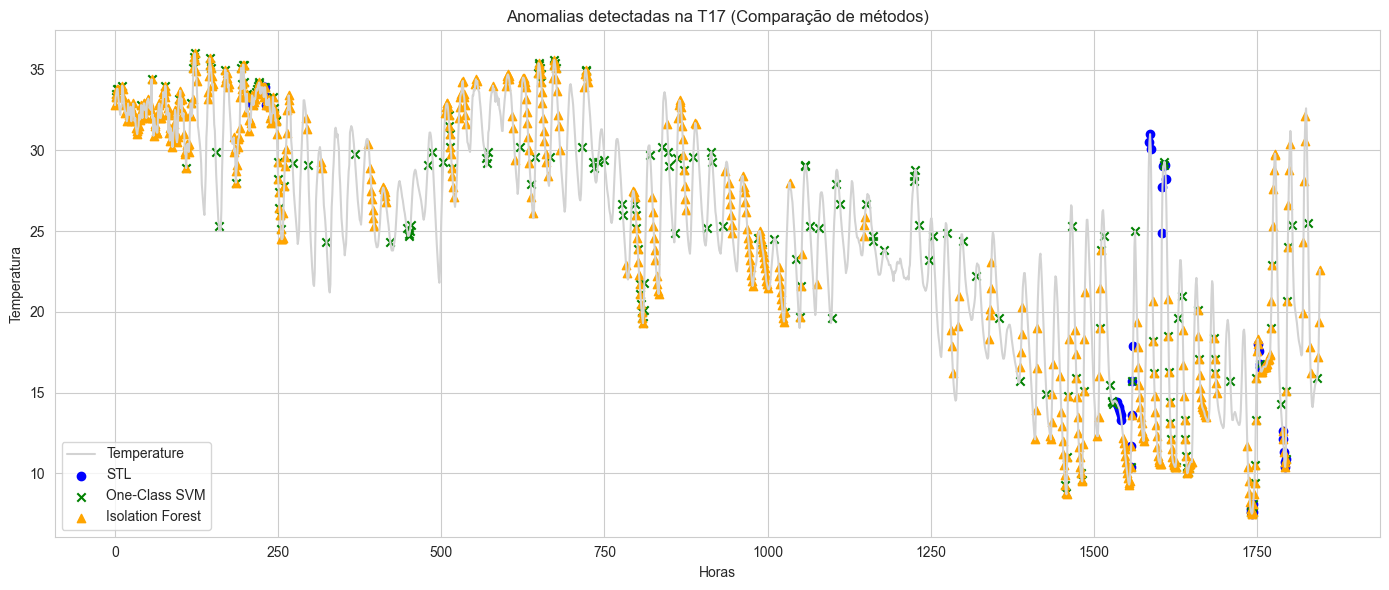

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['T17'], color='lightgray', label='Temperature')

# STL
plt.scatter(df[df['anomaly_stl']].index, df[df['anomaly_stl']]['T17'],
            color='blue', label='STL', marker='o')

# One-Class SVM
plt.scatter(df[df['anomaly_oneclass']].index, df[df['anomaly_oneclass']]['T17'],
            color='green', label='One-Class SVM', marker='x')

# Isolation Forest
plt.scatter(df[df['anomaly_iforest']].index, df[df['anomaly_iforest']]['T17'],
            color='orange', label='Isolation Forest', marker='^')

plt.title('Anomalias detectadas na T17 (Comparação de métodos)')
plt.xlabel('Horas')
plt.ylabel('Temperatura')
plt.legend()
plt.tight_layout()
plt.show()
